<a href="https://colab.research.google.com/github/Bismarc228/MatStatLab/blob/Lab2/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Статистика для анализа данных
Лабораторная работа 2
Описательная статистика

# 1. Основная информация по отчету

## Выполнил - Светлов Ярослав Геннадьевич, 467390, ИИИ 1.1

#Ход работы



**Цель работы:**

1. Сгенерировать две выборки объёмом N = 1000: из дискретного распределения Пуассона (λ=3) и непрерывного нормального $\mathcal{N}(0, 1)$.
2. Рассчитать основные описательные характеристики и построить графики.
3. Исследовать устойчивость характеристик нормального распределения при добавлении выбросов.


#Основная часть

## 1. Генерация выборок

В этом разделе импортируем необходимые библиотеки и создаём две выборки:

- **Пуассон(3)**: дискретное распределение с параметром λ = 3.
- **Нормальное(0,1)**: непрерывное нормальное распределение со средним 0 и стандартным отклонением 1.

Для удобства результаты упакуем в объекты `pd.Series`.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Параметры
N = 1000
lambda_poisson = 3
mu, sigma = 0, 1

# Генерация выборок
sample_poisson = np.random.poisson(lam=lambda_poisson, size=N)
sample_normal = np.random.normal(loc=mu, scale=sigma, size=N)

# Series для удобства
s_poisson = pd.Series(sample_poisson, name='Poisson(3)')
s_normal = pd.Series(sample_normal, name='Normal(0,1)')

## 2. Описательная статистика

**2.1 Формулы**

1. **Квантили** .  
   \\(Q_1\\) (25%-квантиль), \\(Q_2\\) (медиана), \\(Q_3\\) (75%-квантиль).

2. **Среднее арифметическое**  
    $ \bar{x} = \frac{1}{n} ∑^n_{i = 1}x_i $

3. **Медиана**  
   Соответствует $Q_2$

4. **Мода**  
   Наиболее часто встречающееся значение.

5. **Размах**  
   $ R = (0-квантиль) - (1-квантиль)$

6. **IQR**  
   $  IQR = Q_3 - Q_1$

7. **Выборочная дисперсия**  
   $\tilde{S}^2_n = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2$

8. **Стандартное отклонение**  
   $\tilde{S} = \sqrt{\tilde{S}^2_n}$

9. **Коэффициент вариации**  
     $c_v = \\frac{\tilde{S}}{\bar{x}}$

10. **Среднее абсолютное отклонение (MAD)**  
   $MAD = \frac{1}{n} \sum_{i=1}^n |x_i - \bar{x}|$

11. **Асимметрия**  
   $  \gamma_1 = \frac{\frac{1}{n} \sum (x_i - \bar{x})^3}{(\frac{1}{n} \sum (x_i - \overline{x})^2)^{3/2}}$

12. **Эксцесс**  
   $\gamma_2 = \frac{\frac{1}{n} \sum (x_i - \bar{x})^4}{(\frac{1}{n} \sum (x_i - \overline{x})^2)^2} - 3$

13. **Начальный момент \\(k\\)-го порядка**  
  $a_k = \frac{1}{n} \sum_{i=1}^n x_i^k$

14. **Центральный момент \\(k\\)-го порядка**  
  $m_k = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^k$

In [2]:
# Функция описательной статистики
def describe_series(s: pd.Series):
    Q1, Q2, Q3 = np.percentile(s, [25, 50, 75])
    mean = s.mean()
    stats_dict = {
        'Q1': Q1, 'Медиана (Q2)': Q2, 'Q3': Q3,
        'Среднее': mean,
        'Мода': s.mode().iloc[0],
        'Размах': s.max() - s.min(),
        'IQR': Q3 - Q1,
        'Дисперсия': s.var(ddof=1),
        'Стандартное отклонение': s.std(ddof=1),
        'Коэффициент вариации': s.std(ddof=1) / mean if mean != 0 else np.nan,
        'Среднее абсолютное отклонение': np.mean(np.abs(s - mean)),
        'Асимметрия': s.skew(),
        'Эксцесс': s.kurtosis()
    }
    # Моменты
    for k in range(1, 6):
        stats_dict[f'Начальный момент {k} порядка'] = stats.moment(s, moment=k)
        stats_dict[f'Центральный момент {k} порядка'] = stats.moment(s, moment=k, center=mean)
    return pd.Series(stats_dict)

# Подсчёт
stats_poisson = describe_series(s_poisson)
stats_normal = describe_series(s_normal)

# Таблица результатов
pd.DataFrame([stats_poisson, stats_normal], index=['Пуассон(3)', 'Нормальное(0,1)'])

,Q1,Медиана (Q2),Q3,Среднее,Мода,Размах,IQR,Дисперсия,Стандартное отклонение,Коэффициент вариации,...,Начальный момент 1 порядка,Центральный момент 1 порядка,Начальный момент 2 порядка,Центральный момент 2 порядка,Начальный момент 3 порядка,Центральный момент 3 порядка,Начальный момент 4 порядка,Центральный момент 4 порядка,Начальный момент 5 порядка,Центральный момент 5 порядка
Пуассон(3),2.000000,3.000000,4.000000,3.124000,3.000000,9.000000,2.000000,2.977602,1.725573,0.55236,...,0.0,-2.238210e-16,2.974624,2.974624,2.423533,2.423533,26.689264,26.689264,60.547270,60.547270
"Нормальное(0,1)",-0.671183,-0.012263,0.713029,0.008778,-3.016547,6.446225,1.384211,1.062076,1.030571,117.40217,...,0.0,0.000000e+00,1.061014,1.061014,0.086052,0.086052,3.292254,3.292254,0.748701,0.748701


## 3. Визуализация графиков

### 3.1. Эмпирическая функция распределения (eCDF)

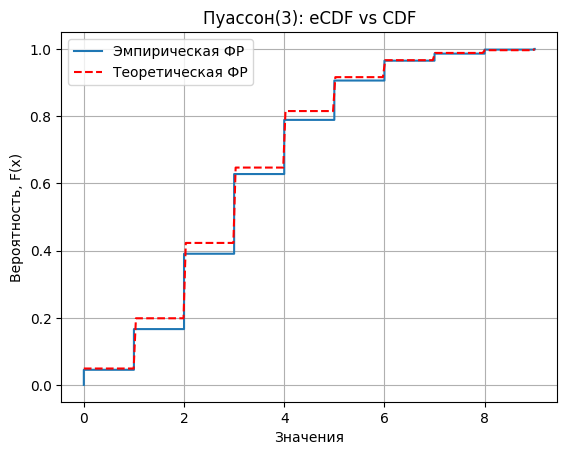

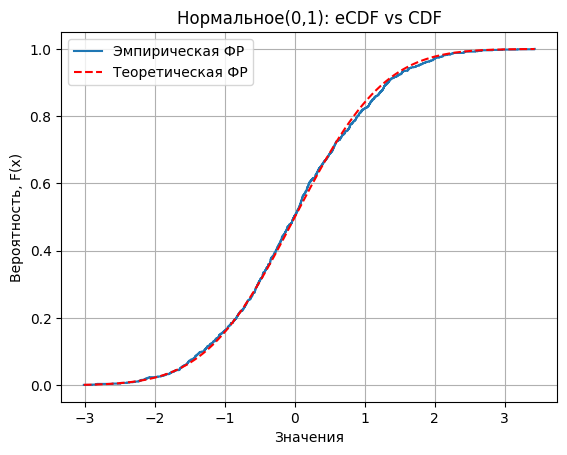

In [3]:
def plot_ecdf(s, cdf_func, params, title):
    x = np.sort(s)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label='Эмпирическая ФР')
    xs = np.linspace(x.min(), x.max(), 200)
    plt.plot(xs, cdf_func(xs, *params), 'r--', label='Теоретическая ФР')
    plt.title(title)
    plt.xlabel('Значения')
    plt.ylabel('Вероятность, F(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_ecdf(s_poisson, stats.poisson.cdf, (lambda_poisson,), 'Пуассон(3): eCDF vs CDF')
plot_ecdf(s_normal, stats.norm.cdf, (mu, sigma), 'Нормальное(0,1): eCDF vs CDF')

### 3.2. Гистограмма и теоретическая плотность (PDF)

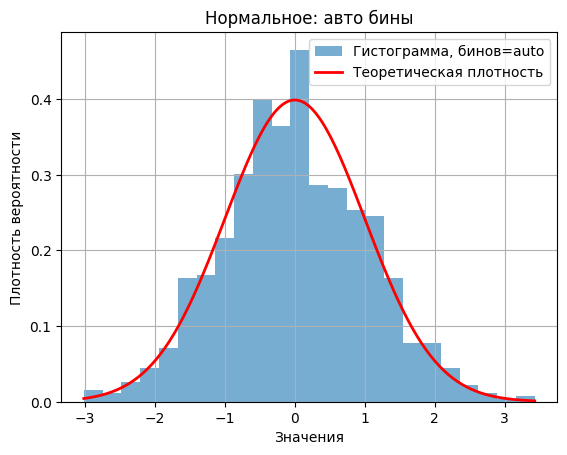

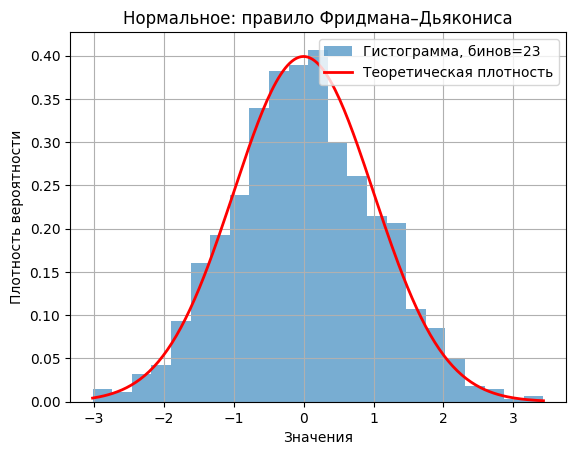

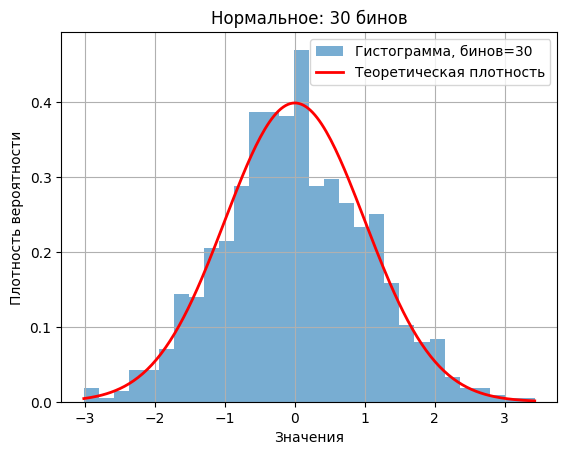

In [4]:
def plot_hist_with_pdf(data, pdf_func, params, bins, title):
    plt.hist(data, bins=bins, density=True, alpha=0.6, label=f'Гистограмма, бинов={bins}')
    xs = np.linspace(data.min(), data.max(), 200)
    plt.plot(xs, pdf_func(xs, *params), 'r-', linewidth=2, label='Теоретическая плотность')
    plt.title(title)
    plt.xlabel('Значения')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True)
    plt.show()

# Автоматический подбор бинов
plot_hist_with_pdf(s_normal, stats.norm.pdf, (mu, sigma), 'auto', 'Нормальное: авто бины')
# Правило Фридмана-Дьякониса
iqr = np.percentile(s_normal,75) - np.percentile(s_normal,25)
bin_width = 2 * iqr / np.cbrt(N)
bins_fd = int((s_normal.max() - s_normal.min())/bin_width)
plot_hist_with_pdf(s_normal, stats.norm.pdf, (mu, sigma), bins_fd, 'Нормальное: правило Фридмана–Дьякониса')
# Ручной выбор
plot_hist_with_pdf(s_normal, stats.norm.pdf, (mu, sigma), 30, 'Нормальное: 30 бинов')

### 3.3. Многоугольник вероятности (PMF)

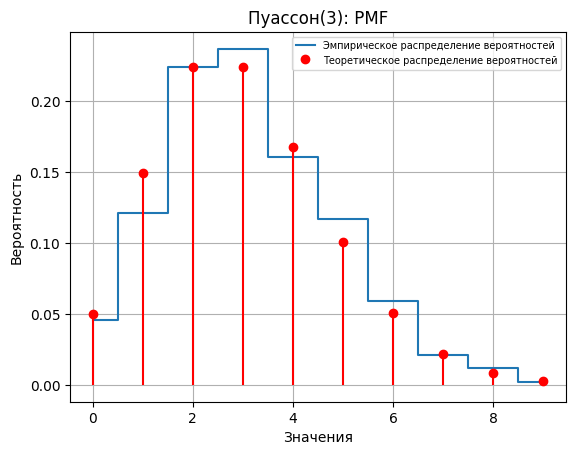

In [13]:
counts = s_poisson.value_counts().sort_index()
probs = counts / counts.sum()
plt.step(probs.index, probs.values, where='mid', label='Эмпирическое распределение вероятностей')
xs = np.arange(counts.index.min(), counts.index.max()+1)
plt.stem(xs, stats.poisson.pmf(xs, lambda_poisson), 'r', markerfmt='ro', basefmt=' ', label='Теоретическое распределение вероятностей')
plt.title('Пуассон(3): PMF')
plt.xlabel('Значения')
plt.ylabel('Вероятность')
plt.legend(loc=1, fontsize=7)
plt.grid(True)
plt.show()

### 3.4. Диаграмма размаха (Boxplot)

<ipython-input-6-bca46a55354b>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s_poisson, s_normal], labels=['Пуассон(3)', 'Нормальное(0,1)'], showfliers=True)


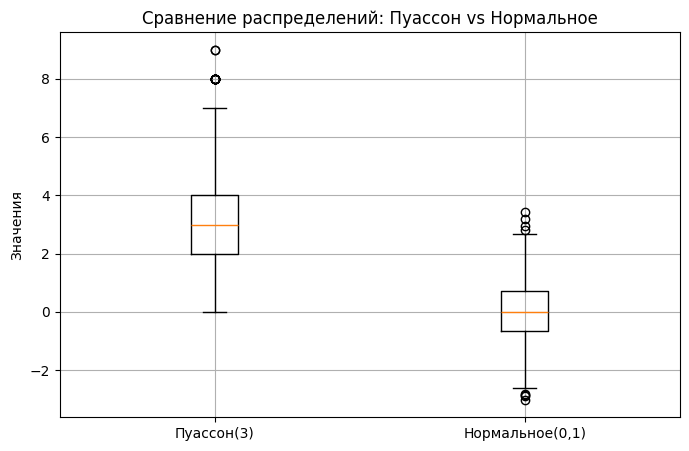

In [6]:
plt.figure(figsize=(8,5))
plt.boxplot([s_poisson, s_normal], labels=['Пуассон(3)', 'Нормальное(0,1)'], showfliers=True)
plt.title('Сравнение распределений: Пуассон vs Нормальное')
plt.ylabel('Значения')
plt.grid(True)
plt.show()

## 4. Устойчивость характеристик при выбросах

In [7]:
# Генерация выбросов
N_outliers = int(0.05 * N)
candidates = np.random.normal(loc=mu, scale=sigma, size=N_outliers*20)
outliers = candidates[np.abs(candidates) > 4*sigma]
while len(outliers) < N_outliers:
    extra = np.random.normal(loc=mu, scale=sigma, size=N_outliers)
    outliers = np.concatenate([outliers, extra[np.abs(extra) > 4*sigma]])
outliers = outliers[:N_outliers]

# Функция мер вариабельности
def variability_measures(series):
    return {
        'Размах': series.max() - series.min(),
        'IQR': series.quantile(0.75) - series.quantile(0.25),
        'Дисперсия': series.var(ddof=1),
        'Стандартное отклонение': series.std(ddof=1),
        'Среднее абсолютное отклонение': np.mean(np.abs(series - series.mean()))
    }

# Сбор результатов
percentages = np.linspace(0, 0.05, 11)
results = []
for p in percentages:
    n_add = int(p * N)
    s_mix = pd.concat([s_normal, pd.Series(np.random.choice(outliers, size=n_add))], ignore_index=True)
    vm = variability_measures(s_mix)
    vm['Процент выбросов'] = p*100
    results.append(vm)
df_var = pd.DataFrame(results)
df_var

,Размах,IQR,Дисперсия,Стандартное отклонение,Среднее абсолютное отклонение,Процент выбросов
0,6.446225,1.384211,1.062076,1.030571,0.820073,0.0
1,8.540277,1.391665,1.143171,1.069192,0.836770,0.5
2,8.814646,1.401240,1.227439,1.107898,0.853485,1.0
3,9.328648,1.405878,1.311998,1.145425,0.870563,1.5
4,9.072529,1.432318,1.391631,1.179674,0.887252,2.0
5,9.072529,1.434713,1.472076,1.213291,0.903488,2.5
6,9.359967,1.446126,1.544773,1.242889,0.918791,3.0
7,9.462603,1.451206,1.627764,1.275839,0.935155,3.5
8,9.478798,1.459279,1.719253,1.311203,0.952186,4.0
9,9.343771,1.471390,1.789429,1.337695,0.967344,4.5


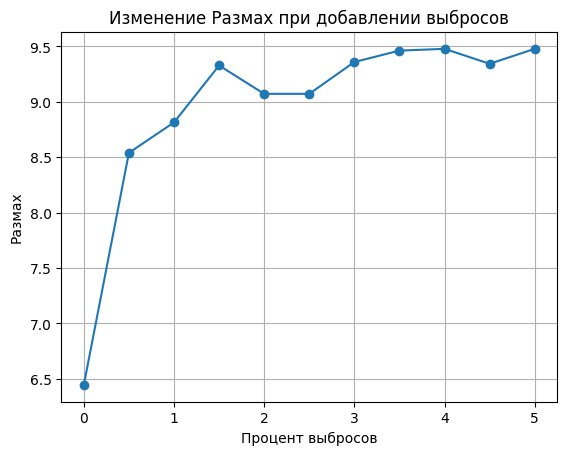

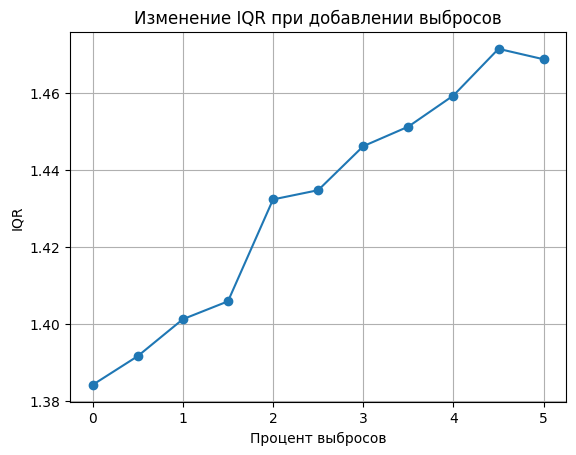

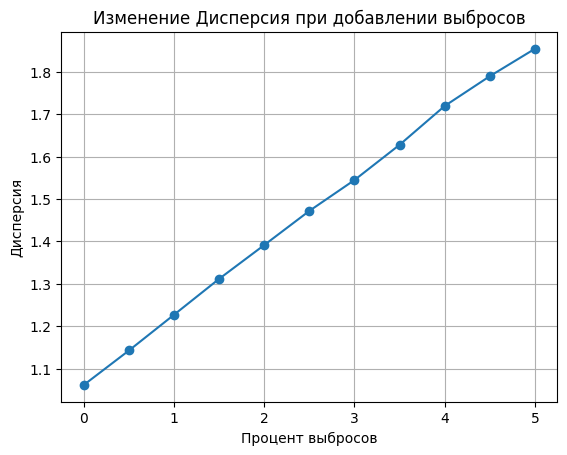

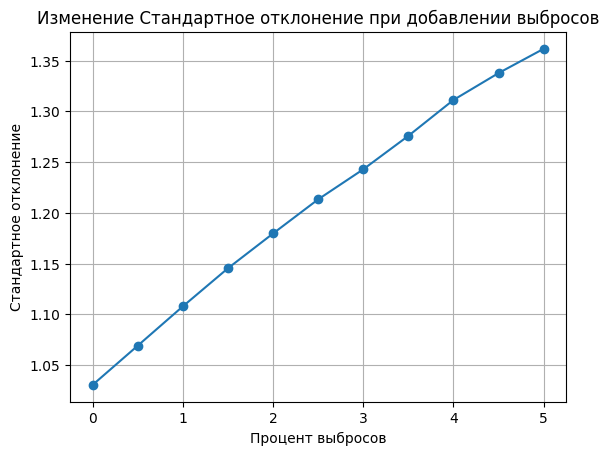

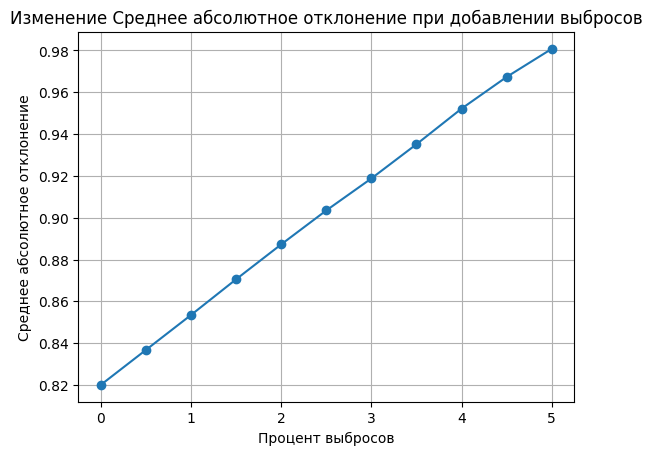

In [8]:
# Графики устойчивости
for measure in ['Размах','IQR','Дисперсия','Стандартное отклонение','Среднее абсолютное отклонение']:
    plt.figure()
    plt.plot(df_var['Процент выбросов'], df_var[measure], marker='o')
    plt.title(f'Изменение {measure} при добавлении выбросов')
    plt.xlabel('Процент выбросов')
    plt.ylabel(measure)
    plt.grid(True)
    plt.show()

#Заключение

Выводы

1. **Отличия распределений:** дискретное и непрерывное отличаются формой, размахом и характером выбросов.
2. **Устойчивость:** размах мало меняются при выбросах, а среднее, дисперсия и размах сильно чувствительны.
3. Этот ноутбук служит конспектом для будущего анализа данных и моделирования.
